In [3]:

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import uproot
import torch
from torch import nn, optim
import pathlib
import os
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.model_selection import train_test_split
import seaborn as sns
from sklearn import preprocessing
from sklearn.preprocessing import QuantileTransformer, PowerTransformer
#https://link.springer.com/content/pdf/10.1007/978-981-96-7005-5.pdf
# https://www.youtube.com/watch?v=qiUEgSCyY5o

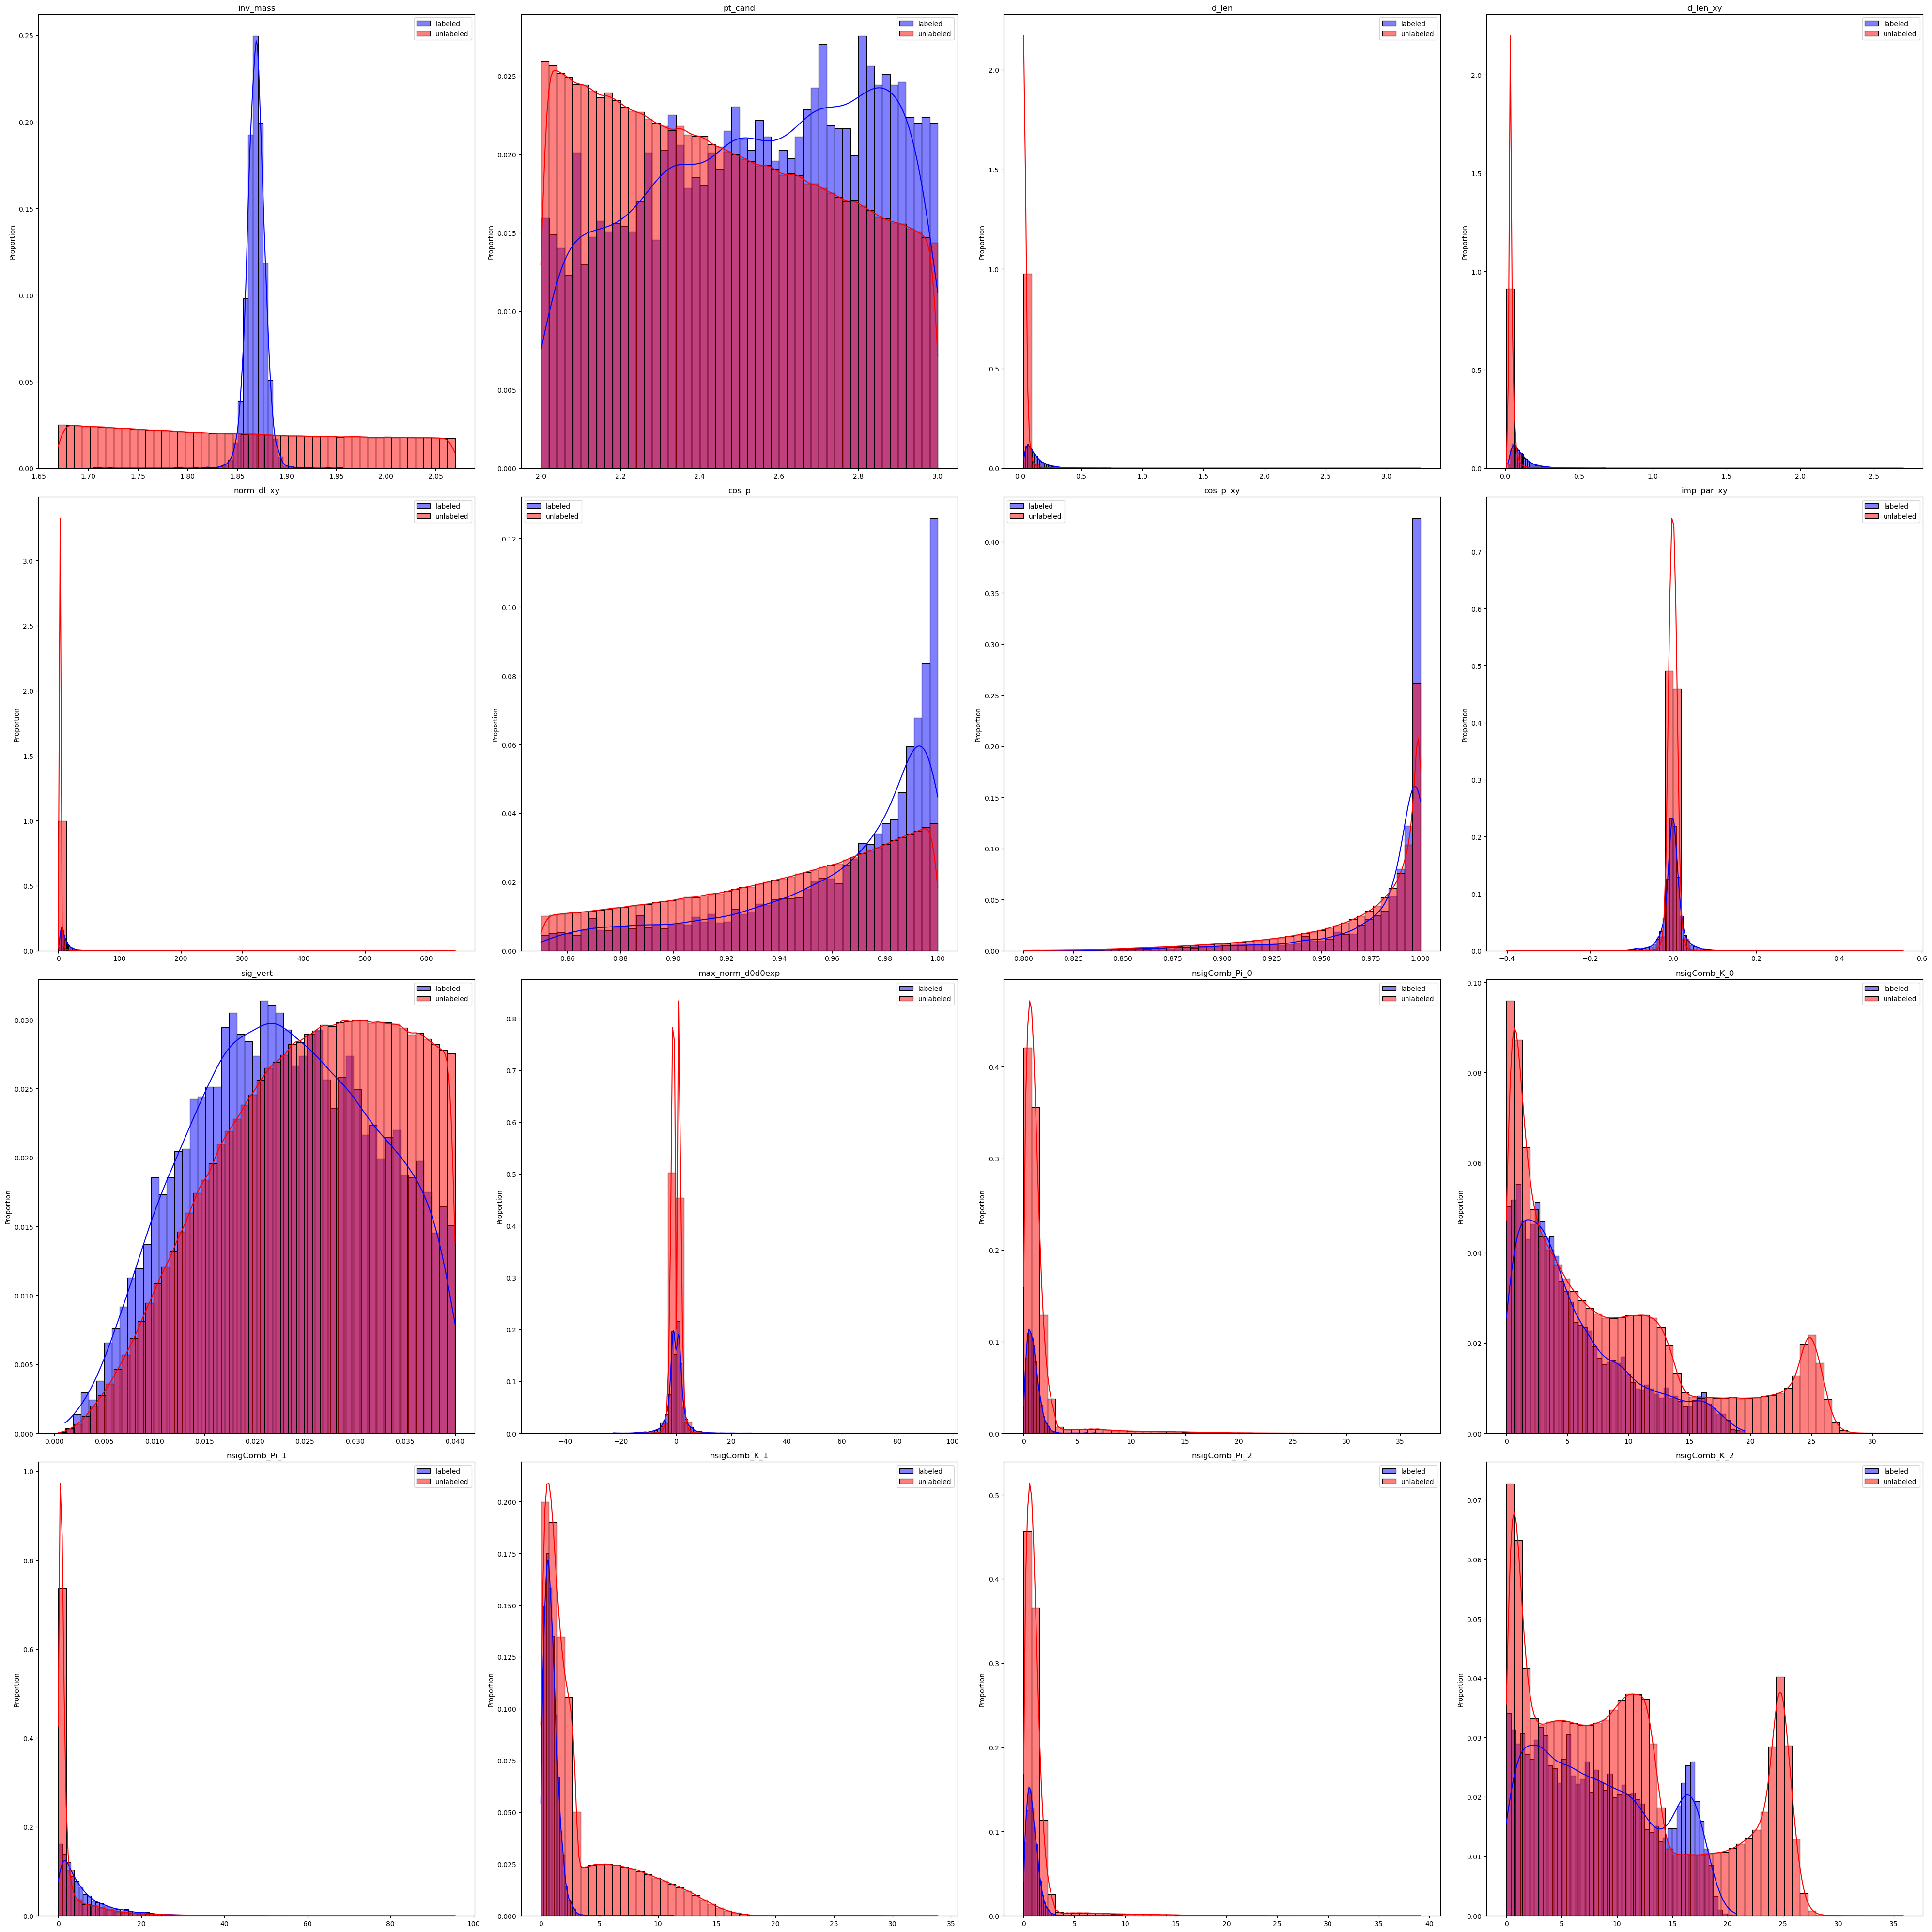

In [4]:
## _-------------------------- Inladen van de data uit de data bestanden

def loader_to_tensor(loader):
    all_data = []
    for batch in loader:
        # batch is a tuple (features,) because no labels
        all_data.append(batch[0])
    return torch.cat(all_data, dim=0)

# Get the data of the simulated outliers.
with uproot.open(pathlib.Path(r"Training_Data\FD.root")) as file:
    tree = file['treeMLDplus']
    branches = tree.keys()
    training_data_FD = tree.arrays(branches, library="np")
    labeled_anomaly_data_tensor = torch.tensor(pd.DataFrame(training_data_FD).values)

# Get the unlabeled data. Since this data file is very large and we do not use all of it for training, limit to 10.000 datapoints for now
with uproot.open(pathlib.Path(r"Training_Data\data.root")) as file_test:
    tree_test = file_test['treeMLDplus']
    branches_test = tree_test.keys()
    training_data_bkg = tree_test.arrays(branches_test, library="np")
    training_data_bkg_df = pd.DataFrame(training_data_bkg)
    unlabeled_data_tensor = torch.tensor(training_data_bkg_df.values)


fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()
for i, col in enumerate(branches):
    sns.histplot(labeled_anomaly_data_tensor[:, i], bins=50, color='blue', alpha=0.5, label='labeled', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(unlabeled_data_tensor[:, i], bins=50, color='red', alpha=0.5, label='unlabeled', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()



Normaliseer de gelabelede data met een yeo-johnson transformatie, zodat de distributie een mean van 0 heeft en een std van 1. Pas deze transform ook toe op de ongelabelede data.

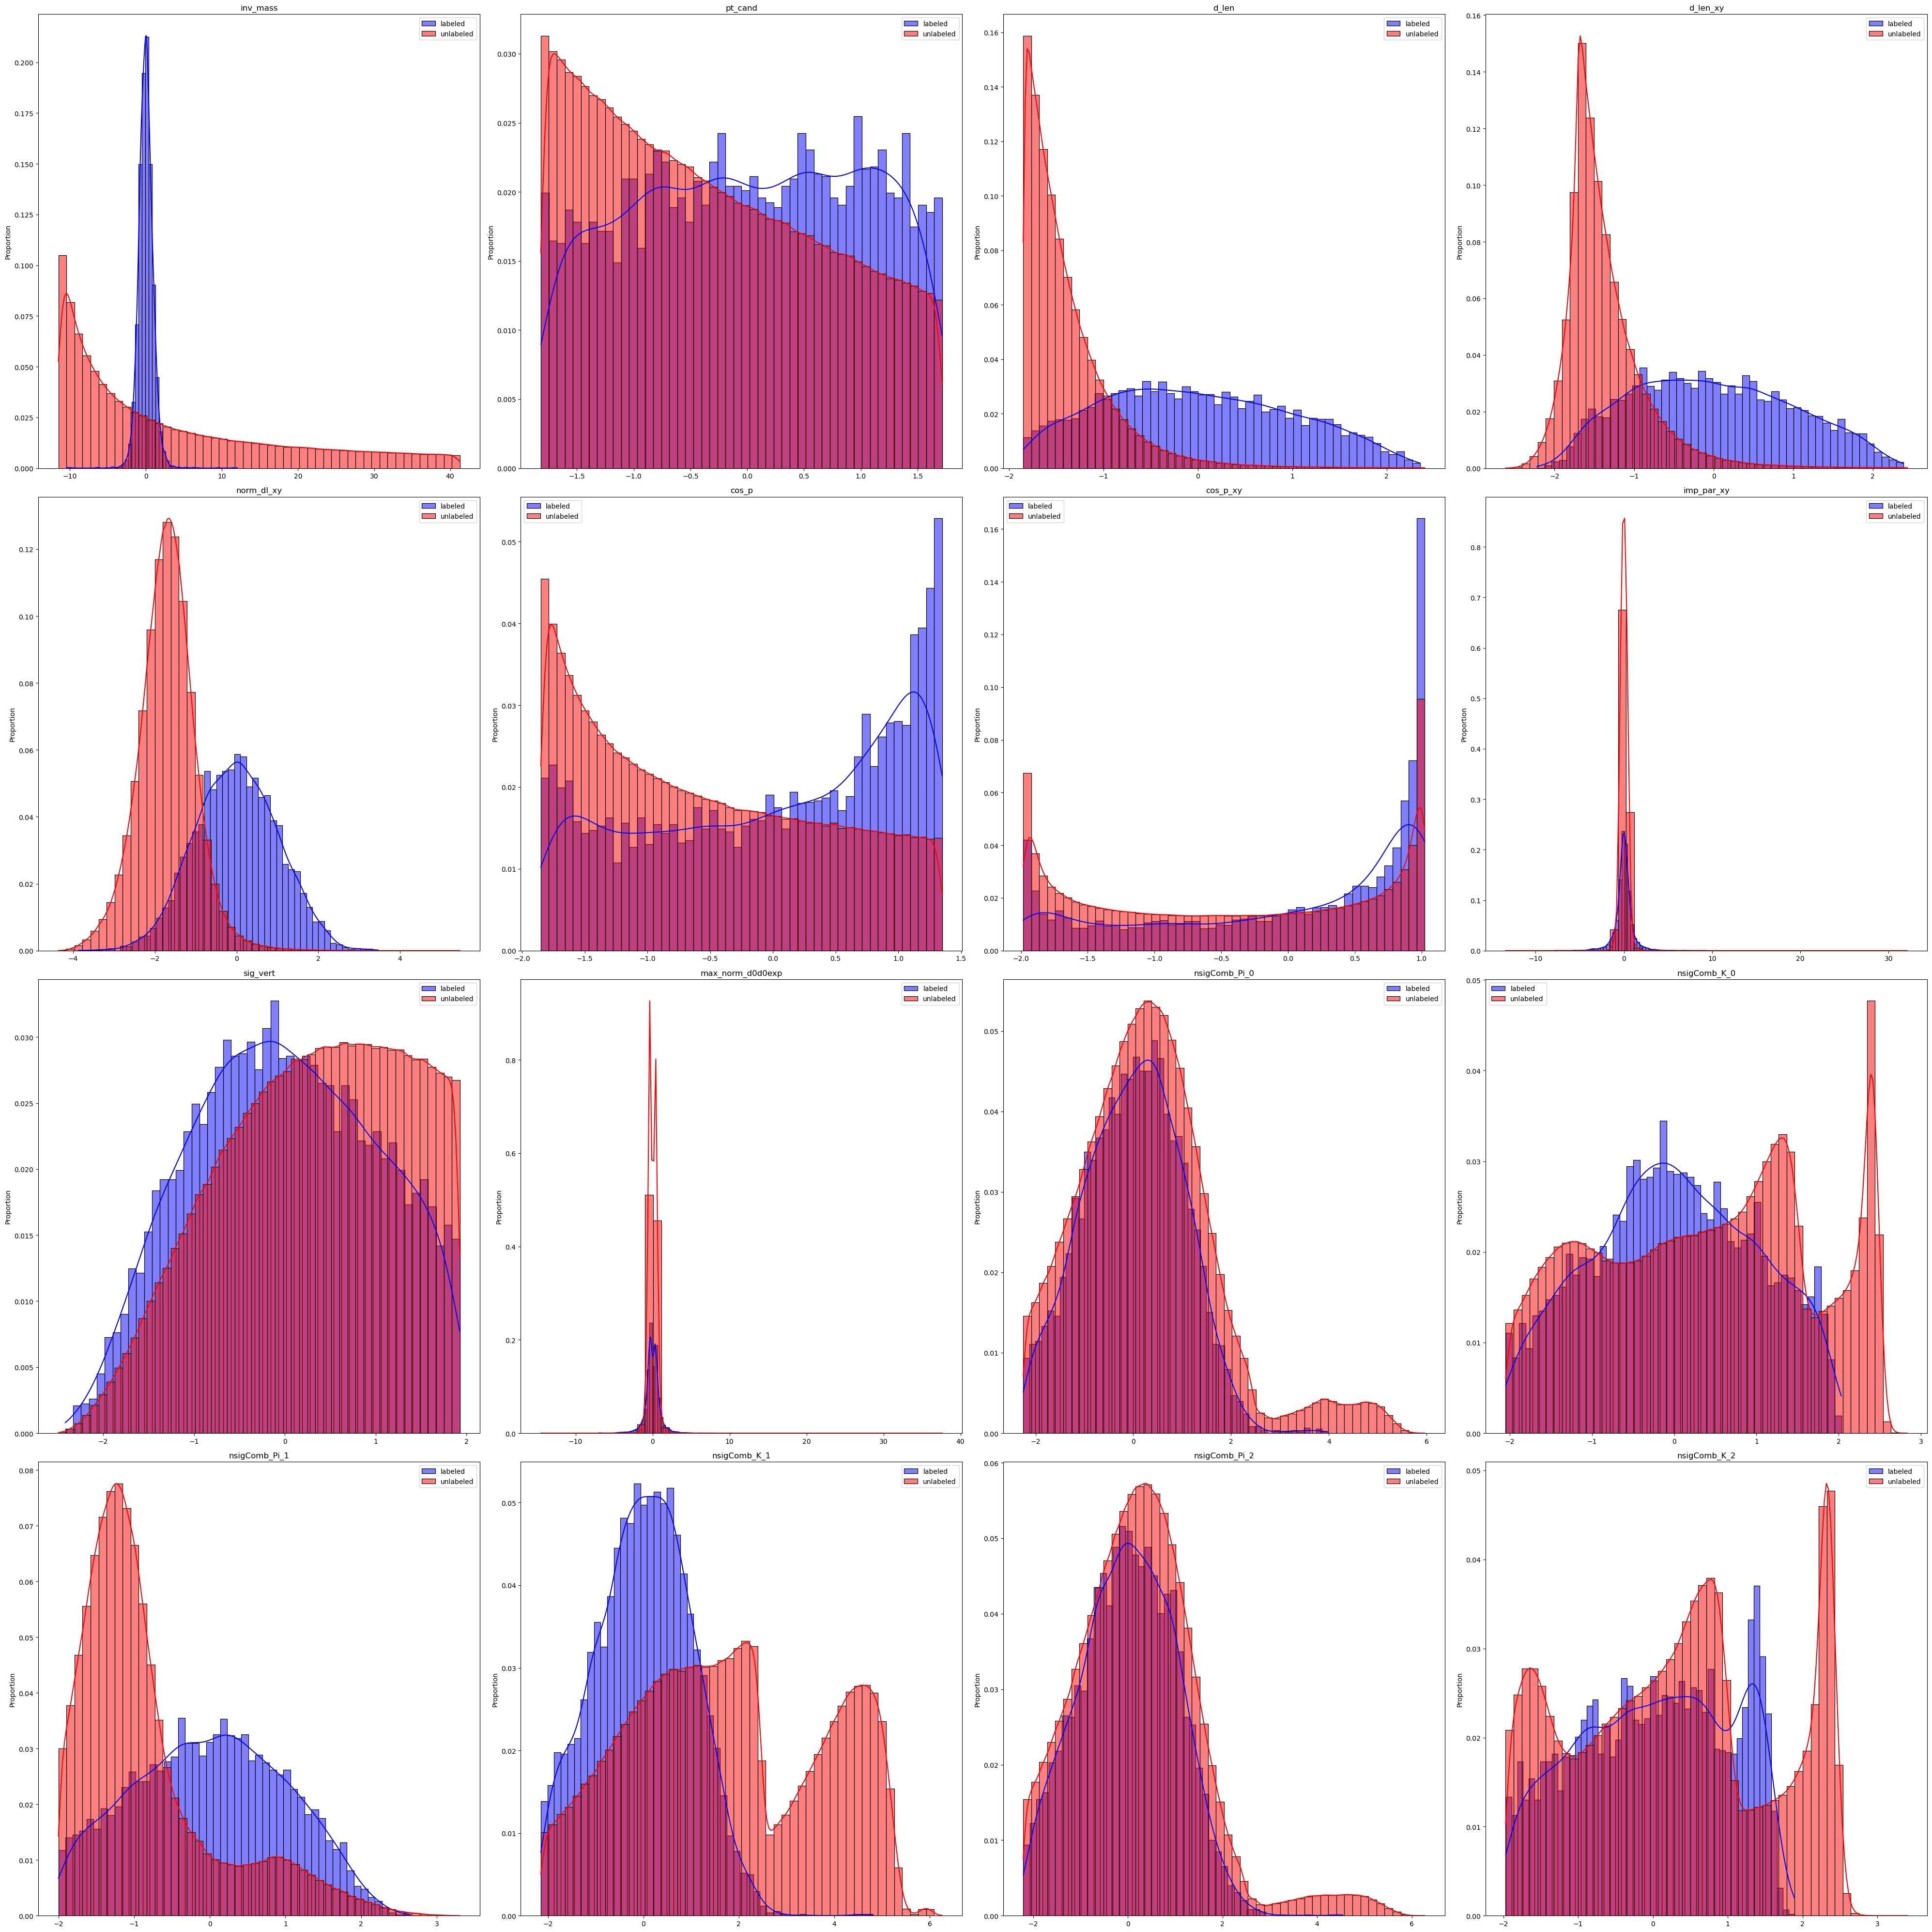

In [5]:
from torch.utils.data import ConcatDataset
# Normalize each feature, according to the type of distribution it seems to follow to optimise performance

#! TODO explain the differences in transformation methods, and why different methods do and do not work here
# de quantiletransformer kan niet worden gefit op de trainingsdata bijvoorbeeld en dan gebruikt op beide, omdat die data buiten bereik van trainingsdata clipt.

qt = PowerTransformer(method="yeo-johnson",standardize=True)
qt.fit(labeled_anomaly_data_tensor)

labeled_anomaly_data_tensor_normalised = qt.transform(labeled_anomaly_data_tensor).astype(np.float32)
label__labeled_data_tensor = torch.tensor(np.ones(labeled_anomaly_data_tensor.shape[0]))
unlabeled_data_tensor_normalised = qt.transform(unlabeled_data_tensor).astype(np.float32)
label_unlabeled_data_tensor = torch.tensor(np.zeros(unlabeled_data_tensor_normalised.shape[0]))

# Dont power transform the inv_mass, so that bump hunting will be easier later on.
# labeled_anomaly_data_tensor_normalised[:,0] = labeled_anomaly_data_tensor[:,0]
# unlabeled_data_tensor_normalised[:,0] = unlabeled_data_tensor[:,0]

# Split the data into:
# 1. a labeled anomaly training set, to train the KDAE on
# 2. A mix of labeled anomaly data and unlabeled noise, to verify the KDAE on
labeled_train, labeled_test = train_test_split(labeled_anomaly_data_tensor_normalised,test_size=0.2) # Use this to train the model
# mixed_data_tensor = labeled_test+unlabeled_data_tensor_normalised # Use this to find whether the model can separate the D+ from the not D+

fig, axes = plt.subplots(4,4, figsize=(40, 40))
axes = axes.flatten()
for i, col in enumerate(branches):
    sns.histplot(labeled_anomaly_data_tensor_normalised[:, i], bins=50, color='blue', alpha=0.5, label='labeled', ax=axes[i],kde=True,stat='proportion')
    sns.histplot(unlabeled_data_tensor_normalised[:, i], bins=50, color='red', alpha=0.5, label='unlabeled', ax=axes[i],kde=True,stat='proportion')
    axes[i].set_title(col)
    axes[i].legend()

plt.tight_layout()
plt.show()

# dataset_test = TensorDataset(features_test)     # No labels
# loader_test = DataLoader(dataset_test, batch_size=2000, shuffle=True)
labeled_tensor = torch.tensor(labeled_anomaly_data_tensor_normalised)
unlabeled_tensor = torch.tensor(unlabeled_data_tensor_normalised)
labeled_inv_mass = labeled_tensor[:,0]
unlabeled_inv_mass = unlabeled_tensor[:,0]
labeled_tensor = labeled_tensor[:,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]]
unlabeled_tensor = unlabeled_tensor[:,[1,2,3,4,5,6,7,8,9,10,11,12,13,14,15]]

# train_data, val_data = random_split(labeled_tensor, [1200, 600])
labeled_dataset = TensorDataset(labeled_tensor,label__labeled_data_tensor,labeled_inv_mass)
unlabeled_dataset = TensorDataset(unlabeled_tensor,label_unlabeled_data_tensor,unlabeled_inv_mass)

train_size = int(0.8 * len(labeled_dataset))
test_size = len(labeled_dataset) - train_size

# Split the dataset
KDAE_train_dataset, labeled_test_dataset = random_split(labeled_dataset, [train_size,test_size],generator=torch.Generator().manual_seed(42))

# 
loader_noise_data = DataLoader(unlabeled_dataset, batch_size=2000)
loader_KDAE_train_data = DataLoader(KDAE_train_dataset, batch_size=2000, shuffle=True)
KDAE_test_data = ConcatDataset([labeled_test_dataset,unlabeled_dataset])
loader_mixed_data = DataLoader(KDAE_test_data, batch_size=2000, shuffle=True)


Definieer de Auto Encoder

In [6]:
# Definieer een auto encoder neural network. Dit type neural network bgint met de volledige 16 parameters, comprimeert ze in steeds kleinere lagen
# Totdat het de kleinste laag van maar twee neuronen bereikt. Daarna probeert het hiermee weer de originele parameters te recreeëren
# Dit model leert dus voor het signaal van D+ deeltjes hoe de data er ongeveer uitziet. Het verschil tussen de input en output parameters
# Voor D+ deeltjes zou dus heel klein moeten zijn, en de error dus klein. Maar het model is niet getrained op alle andere deeltjes.
# De verwachting is dus dat andere deeltjes die geen D+ deeltjes zijn, de autoencoder heel slecht zal zijn in de parameters recreeëren zonder extra training.
# Zo kan de error van het netwerk gebruikt worden als classificatie van wel of niet D+ deeltjes.
import torch
import torch.nn as nn
from typing import List


def make_mlp(
    dims: List[int],
    activation=nn.LeakyReLU(0.1),
    norm=True,
    last_activation=False
):
    layers = []

    for i in range(len(dims) - 1):
        layers.append(nn.Linear(dims[i], dims[i + 1]))

        if i < len(dims) - 2 or last_activation:
            if norm:
                layers.append(nn.LayerNorm(dims[i + 1]))
            layers.append(activation)

    return nn.Sequential(*layers)


class Autoencoder(nn.Module):
    def __init__(
        self,
        latent_dim: int = 4,
        depth: int = 3,
        hidden_dim: int = 8,
        shrink_factor: float = 0.5,
        norm: bool = True,
        activation=nn.LeakyReLU(0.1),
    ):
        super().__init__()
        input_dim = 15
        # Build encoder dimensions
        encoder_dims = [input_dim]
        current_dim = hidden_dim

        for _ in range(depth):
            encoder_dims.append(current_dim)
            current_dim = max(int(current_dim * shrink_factor), latent_dim)

        encoder_dims.append(latent_dim)

        # Decoder mirrors encoder
        decoder_dims = encoder_dims[::-1]

        self.shrinking = make_mlp(
            encoder_dims,
            activation=activation,
            norm=norm,
            last_activation=False
        )

        self.growing = make_mlp(
            decoder_dims,
            activation=activation,
            norm=norm,
            last_activation=False
        )

    def forward(self, x):
        z = self.shrinking(x)
        return self.growing(z)




Train de auto-encoder

In [7]:
import torch
import torch.nn.functional as F

def kde_loss(latent, epsilon=1e-6, bandwidth=0.1):
    """
    Computes the KDE-based amplified latent representation loss.
    Args:
        latent: Tensor of shape (batch_size, latent_dim)
        epsilon: Small constant to avoid log(0)
        bandwidth: Bandwidth for the Gaussian kernel
    Returns:
        Lr: Scalar tensor representing latent regularization loss
    """
    batch_size, latent_dim = latent.shape
    Lr = 0.0
    
    # Compute KDE for each latent dimension
    for j in range(latent_dim):
        # Extract the j-th latent dimension across all samples
        latent_j = latent[:, j].unsqueeze(1)  # shape: (batch_size, 1)
        
        # Compute pairwise differences
        diff = latent_j - latent_j.T  # shape: (batch_size, batch_size)
        
        # Gaussian kernel
        k = torch.exp(-0.5 * (diff / bandwidth)**2) / (bandwidth * torch.sqrt(torch.tensor(2 * torch.pi)))
        
        # KDE estimate: sum over all samples
        kde = k.sum(dim=1) / batch_size  # shape: (batch_size,)
        
        # Amplified latent representation loss: negative log of max density
        Lr += torch.min(-torch.log(kde + epsilon))  # min over batch as in Eq.4
    
    return Lr / latent_dim  # average over dimensions


def loss_function(reconstructed, features, latent, alpha=.3):
    """
    Combined loss: reconstruction + amplified latent representation
    Args:
        reconstructed: Tensor of shape (batch_size, feature_dim)
        features: Original input tensor (batch_size, feature_dim)
        latent: Latent representation tensor (batch_size, latent_dim)
        alpha: Weight for latent loss
    Returns:
        total_loss: Scalar tensor
    """
    # Reconstruction loss: MAE
    Lc = F.l1_loss(reconstructed, features, reduction='sum')
    
    # Size of the peak of the kde in the latent layers. Encourage a large peak in the kde of the latent layer, as done in the paper referred to earlier.
    Lr = kde_loss(latent)
    
    # Total loss
    total_loss = Lc + alpha * Lr
    return total_loss

# Given all hyperparameters such as the model architecture, the loss function, the learning rate, optimise the model
def train_model(model_2D, loader, loss_function=loss_function, alpha=0.3, learning_rate=1e-3, weight_decay=1e-5, epochs = 150, device = torch.device("cuda" if torch.cuda.is_available() else "cpu")):
    optimizer = optim.Adam(model_2D.parameters(), lr=learning_rate, weight_decay=weight_decay,)
    model_2D.to(device)
    outputs = []
    loss_vs_epoch = []
    for epoch in range(epochs):
        total_loss = 0
        for batch, label, inv_mass in loader:
            features = batch.to(device)
            
            reconstructed = model_2D(features)
            latent = model_2D.shrinking(features)
            loss = loss_function(reconstructed, features,latent, alpha)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
        loss_vs_epoch.append(total_loss)
        outputs.append((epoch, features, reconstructed))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss/(2000*15):.6f}")
    return loss_vs_epoch, outputs, model_2D


Plot de score van het model om te onderscheiden tussen de gelabelde en ongelabelde data

In [8]:
def collect_latent_and_error(model, dataloader, device):
    model.eval()

    latents = []
    recon_errors = []
    labels = []
    params =[]
    with torch.no_grad():
        for x, y, inv_mass in dataloader:
            x = x.to(device).float()

            z = model.shrinking(x)
            recon = model(x)

            recon_error = torch.mean(np.abs(x - recon), dim=1)

            latents.append(z.cpu().numpy())
            recon_errors.append(recon_error.cpu().numpy())
            labels.append(y.cpu().numpy())
            params.append(inv_mass.cpu().numpy())
    return (
        np.vstack(latents),
        np.concatenate(recon_errors),
        np.concatenate(labels),
        np.concatenate(params)
    )




In [9]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import average_precision_score


def find_ap_score(labels,recon_error):
    return average_precision_score(labels,recon_error), 0

def find_f1_threshold(labels, recon_error, use_macro=False, beta=10):
    # Spread errors to emphasize outliers
    recon_error_log = np.log1p(recon_error)

    # Use percentiles to avoid extreme edges
    thresholds = np.percentile(recon_error_log, np.linspace(5, 95, 1000))

    best_score = -1
    best_threshold = thresholds[0]

    for t in thresholds:
        preds = (recon_error_log > t).astype(int)

        tp = np.sum((preds == 1) & (labels == 1))
        fp = np.sum((preds == 1) & (labels == 0))
        fn = np.sum((preds == 0) & (labels == 1))
        tn = np.sum((preds == 0) & (labels == 0))

        eps = 1e-8

        if use_macro:
            # F1 for positive class
            prec1 = tp / (tp + fp + eps)
            rec1  = tp / (tp + fn + eps)
            f1_pos = 2 * prec1 * rec1 / (prec1 + rec1 + eps)

            # F1 for negative class
            prec0 = tn / (tn + fn + eps)
            rec0  = tn / (tn + fp + eps)
            f1_neg = 2 * prec0 * rec0 / (prec0 + rec0 + eps)

            score = 0.5 * (f1_pos + f1_neg)

        else:
            # F-beta for positive class only
            precision = tp / (tp + fp + eps)
            recall = tp / (tp + fn + eps)
            score = (1 + beta**2) * precision * recall / (
                beta**2 * precision + recall + eps
            )

        if score > best_score:
            best_score = score
            best_threshold = t

    # Transform threshold back
    return np.expm1(best_threshold), best_score




In [10]:
import numpy as np
from scipy.optimize import curve_fit

from scipy.integrate import quad

# Define the different functions we want to fit.
def exponential(x, a, b,c,d):
        # Standard exponential function, shifted to the left to help fitting
        return a*b**(-x-c-11)+d 

def gaussian(x,a,b,c):
    return a*np.exp(-(x)**2/(2*c**2))


def signal_to_background_from_params(gauss_params, exp_params, k=2):

    a_g, b_g, c_g = gauss_params
    a_e, b_e, c_e, d_e = exp_params

    # Integration window
    x_min, x_max = b_g - k*c_g, b_g + k*c_g

    # Integrate Gaussian
    S, _ = quad(lambda x: gaussian(x, a_g, b_g, c_g), x_min, x_max)

    # Integrate Exponential
    B, _ = quad(lambda x: exponential(x, a_e, b_e, c_e, d_e), x_min, x_max)

    # Compute S/B
    S_over_B = S / B

    return S, B, S_over_B

def recall_at_fpr(labels, scores, target_fpr=0.01):
    # scores = anomaly scores (higher = more anomalous)
    neg_scores = scores[labels == 0]

    # Threshold that yields desired FPR
    threshold = np.percentile(neg_scores, 100 * (1 - target_fpr))

    preds = scores > threshold

    tp = np.sum((preds == 1) & (labels == 1))
    fn = np.sum((preds == 0) & (labels == 1))

    recall = tp / (tp + fn + 1e-8)
    return recall

def bump_hunt(candidates,bins=40):
    # Fit an exponential on the data first, then a gaussian.

    # Histogram the data
    hist,bins = np.histogram(candidates,bins=100)
    plt.plot(hist)
    bins = bins[0:-1]
    mask = (bins < -5) & (bins > 5) # Exclude area of interest
    hist_masked, bins_masked = hist[~mask],bins[~mask]

    # Fit exponential outside signal area.
    param, param_cov = curve_fit(exponential,bins_masked,hist_masked)

    def bump_gaussian(x, a, b, c):
        # Combination of exponential and guassian. 
        # If exponential_params= False return just the gaussian. 
        # If the parameters of the exponential are passed, return the combination.
        return exponential(x, *param) + a*np.exp(-(x)**2/(2*c**2))

    param_2, param_cov_2 = curve_fit(bump_gaussian, bins,hist)

    # plot it
    x = np.linspace(-12,40, num=100)
    plt.figure()
    plt.plot(x,bump_gaussian(x,*param_2))
    plt.plot(x,exponential(x,*param))
    plt.plot(x,gaussian(x,*param_2))
    plt.show()

    _,_,SoverB = signal_to_background_from_params(param_2,param)

    # return a list of parameters and covariances
    return [param, param_2], [param_cov, param_cov_2], SoverB



In [11]:
def given_model_parameters_find_signal_to_background_ratio(
        latent_dim,
        depth,
        hidden_dim, 
        shrink_factor,
        learning_rate,
        weight_decay,
        epochs,
        alpha
        ):
    
    # Define and train the model
    loss_vs_epoch, outputs, model = train_model(
        Autoencoder(latent_dim,depth,hidden_dim, shrink_factor), 
        loader_KDAE_train_data,
        learning_rate=learning_rate, 
        weight_decay=weight_decay, 
        epochs = epochs,
        alpha=alpha
        )

    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # Collect mixed data
    latent_test, recon_test, y_test, x_test = collect_latent_and_error(
        model, loader_mixed_data, device
    )

    # --- Predicted labels ---
    best_threshold_f1, best_f1 = find_f1_threshold(y_test,recon_test)
    pred_labels = (recon_test < best_threshold_f1).astype(int)
    signal_mask = recon_test < best_threshold_f1

    # --- Performance evaluation ---
    print(classification_report(y_test, pred_labels))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))

    # We have now classified the signal from the background (not necessarily very well). Give the signal we found in the background noise a label D+ = True
    latent_noise, recon_noise, y_noise, x_noise = collect_latent_and_error(
        model, loader_noise_data, device
    )

    # Apply the classification on the inclusive dataset.
    candidate_mask=recon_noise < best_threshold_f1
    candidates = x_noise[candidate_mask]

    # Hunt the distribution of candidates for a bump
    _,_,SoverB = bump_hunt(candidates)

    print(f"signal to background ratio for this trial is: {SoverB}")

    return SoverB


def given_model_parameters_find_f1_score(
        trial,
        latent_dim,
        depth,
        hidden_dim, 
        shrink_factor,
        learning_rate,
        weight_decay,
        epochs,
        alpha,
        use_macro=False
        ):
    
    # Define and train the model
    loss_vs_epoch, outputs, model = train_model(
        Autoencoder(latent_dim,depth,hidden_dim, shrink_factor), 
        loader_KDAE_train_data,
        alpha=alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        epochs=epochs
        )
    
    # Include the model in the trial object
    trial.set_user_attr("model", model)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # Collect mixed data
    latent_test, recon_test, y_test, x_test = collect_latent_and_error(
        model, loader_mixed_data, device
    )

    # --- Predicted labels ---
    best_threshold_f1, best_f1 = find_f1_threshold(y_test,recon_test,use_macro=False)
    pred_labels = (recon_test < best_threshold_f1).astype(int)
    signal_mask = recon_test < best_threshold_f1

    # --- Performance evaluation ---
    print(classification_report(y_test, pred_labels))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))

    plt.figure(figsize=(8,5))
    sns.histplot(recon_test[y_test==0], color='blue', label='Normal', bins=100, alpha=0.5)
    sns.histplot(recon_test[y_test==1], color='red', label='Outlier', bins=100, alpha=0.5)
    plt.axvline(best_threshold_f1, color='black', linestyle='--', label='Threshold (F1)')
    plt.xlabel("Reconstruction Error")
    plt.ylabel("Density")
    plt.title("Reconstruction Error with Optimized Threshold")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return best_f1

def given_model_parameters_find_recall_at_fpr(
        trial,
        latent_dim,
        depth,
        hidden_dim, 
        shrink_factor,
        learning_rate,
        weight_decay,
        epochs,
        alpha
        ):
    
    # Define and train the model
    loss_vs_epoch, outputs, model = train_model(
        Autoencoder(latent_dim,depth,hidden_dim, shrink_factor), 
        loader_KDAE_train_data,
        alpha=alpha,
        learning_rate=learning_rate,
        weight_decay=weight_decay,
        epochs=epochs
        )
    
    # Include the model in the trial object
    trial.set_user_attr("model", model)
    
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    # Collect mixed data
    latent_test, recon_test, y_test, x_test = collect_latent_and_error(
        model, loader_mixed_data, device
    )

    # --- Predicted labels ---
    recall_at_falsepositiverate = recall_at_fpr(y_test,recon_test,target_fpr=0.05)

    # --- Performance evaluation ---
    print("recall_at_falsepositiverate:\n", recall_at_falsepositiverate)
    best_threshold_f1, best_f1 = find_f1_threshold(y_test,recon_test)
    pred_labels = (recon_test < best_threshold_f1).astype(int)
    signal_mask = recon_test < best_threshold_f1
    print(classification_report(y_test, pred_labels))
    print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))
    return recall_at_falsepositiverate






In [ ]:
#Initialize new study
import optuna
study = optuna.create_study(direction='maximize')

c:\Users\sande\anaconda3\envs\CAML\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-01-17 13:55:11,365] A new study created in memory with name: no-name-637a86c4-0bd6-423f-bfac-aa8ac3009280


In [ ]:
# save a study
import pickle

# Save the sampler with pickle to be loaded later.
with open("test.pkl", "wb") as fout:
    pickle.dump(study.sampler, fout)

In [ ]:
import copy

best_model = None
best_score = float("-inf")

# This is a callback function, it is executed at the end of each trial
# When the model we have found is the best so far, we want to save it.
def save_best_model(study, trial):
    global best_model, best_score

    if study.best_trial.number == trial.number:
        best_score = trial.value
        best_model = copy.deepcopy(trial.user_attrs["model"])

def objective(trial):
    params={'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs': 290, 'alpha': 0.568512304090592}
    # params = {
    #     "latent_dim": trial.suggest_int("latent_dim", 1, 20,log=False),
    #     "depth": trial.suggest_int("depth", 1, 3 ,log=False),
    #     "hidden_dim": trial.suggest_int("hidden_dim", 8, 64,log=True),
    #     "shrink_factor": trial.suggest_float("shrink_factor", 0,1,log=False),
    #     "learning_rate": trial.suggest_float("learning_rate", 1e-5, 1.0e-2,log=True),
    #     "weight_decay": trial.suggest_float("weight_decay",1e-6,1e-3,log=True),
    #     "epochs": trial.suggest_int("epochs",50,300,log=True),
    #     "alpha": trial.suggest_float("alpha",0,1,log=False)
    # }
    print(params)

    model_score = given_model_parameters_find_f1_score(
        trial,
        latent_dim = params['latent_dim'],
        depth = params['depth'],
        hidden_dim = params['hidden_dim'],
        shrink_factor = params['shrink_factor'],
        learning_rate = params['learning_rate'],
        weight_decay = params['weight_decay'],
        epochs = params['epochs'],
        alpha = params['alpha']
        ) 
    
    return model_score

study.optimize(objective, n_trials=1, n_jobs=1,gc_after_trial=True, callbacks=[save_best_model])
print(study.best_trial)

{'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs': 290, 'alpha': 0.568512304090592}
{'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs': 290, 'alpha': 0.568512304090592}
{'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs': 290, 'alpha': 0.568512304090592}
{'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs': 290, 'alpha': 0.568512304090592}
{'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs'

In [ ]:
print(study.best_trial)
print(study.best_params)
print(best_model)

FrozenTrial(number=298, state=1, values=[0.84021824390046], datetime_start=datetime.datetime(2026, 1, 9, 8, 50, 52, 666), datetime_complete=datetime.datetime(2026, 1, 9, 9, 19, 5, 329619), params={'latent_dim': 19, 'depth': 1, 'hidden_dim': 53, 'shrink_factor': 0.815266726208312, 'learning_rate': 0.009970922644898447, 'weight_decay': 0.00041808788573680176, 'epochs': 105, 'alpha': 0.05501063764440288}, user_attrs={'model': Autoencoder(
  (shrinking): Sequential(
    (0): Linear(in_features=15, out_features=53, bias=True)
    (1): LayerNorm((53,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Linear(in_features=53, out_features=19, bias=True)
  )
  (growing): Sequential(
    (0): Linear(in_features=19, out_features=53, bias=True)
    (1): LayerNorm((53,), eps=1e-05, elementwise_affine=True)
    (2): LeakyReLU(negative_slope=0.1)
    (3): Linear(in_features=53, out_features=15, bias=True)
  )
)}, system_attrs={}, intermediate_values={}, distributions

best so far
FrozenTrial(number=29, state=1, values=[0.8923521053014853] (F1_score), datetime_start=datetime.datetime(2026, 1, 8, 18, 41, 36, 525643), datetime_complete=datetime.datetime(2026, 1, 8, 19, 41, 45, 883814), params={'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs': 290, 'alpha': 0.568512304090592}, user_attrs={}, system_attrs={}, intermediate_values={}, distributions={'latent_dim': IntDistribution(high=20, log=False, low=1, step=1), 'depth': IntDistribution(high=3, log=False, low=1, step=1), 'hidden_dim': IntDistribution(high=64, log=True, low=8, step=1), 'shrink_factor': FloatDistribution(high=1.0, log=False, low=0.0, step=None), 'learning_rate': FloatDistribution(high=0.01, log=True, low=1e-05, step=None), 'weight_decay': FloatDistribution(high=0.001, log=True, low=1e-06, step=None), 'epochs': IntDistribution(high=300, log=True, low=50, step=1), 'alpha': FloatDistribution(high=1.0, log=False, low=0.0, step=None)}, trial_id=29, value=None)
{'latent_dim': 14, 'depth': 1, 'hidden_dim': 62, 'shrink_factor': 0.6395786091789358, 'learning_rate': 0.009994343982968336, 'weight_decay': 6.866255767127823e-05, 'epochs': 290, 'alpha': 0.568512304090592}

Epoch 1/290, Loss: 1.831015
Epoch 2/290, Loss: 1.402641
Epoch 3/290, Loss: 1.214358
Epoch 4/290, Loss: 1.061217
Epoch 5/290, Loss: 0.904631
Epoch 6/290, Loss: 0.789319
Epoch 7/290, Loss: 0.705166
Epoch 8/290, Loss: 0.646013
Epoch 9/290, Loss: 0.614337
Epoch 10/290, Loss: 0.587406
Epoch 11/290, Loss: 0.564022
Epoch 12/290, Loss: 0.538324
Epoch 13/290, Loss: 0.512467
Epoch 14/290, Loss: 0.497935
Epoch 15/290, Loss: 0.489091
Epoch 16/290, Loss: 0.475899
Epoch 17/290, Loss: 0.452374
Epoch 18/290, Loss: 0.436372
Epoch 19/290, Loss: 0.434944
Epoch 20/290, Loss: 0.438261
Epoch 21/290, Loss: 0.436853
Epoch 22/290, Loss: 0.418227
Epoch 23/290, Loss: 0.400455
Epoch 24/290, Loss: 0.396777
Epoch 25/290, Loss: 0.403482
Epoch 26/290, Loss: 0.413973
Epoch 27/290, Loss: 0.416507
Epoch 28/290, Loss: 0.403897
Epoch 29/290, Loss: 0.387214
Epoch 30/290, Loss: 0.377222
Epoch 31/290, Loss: 0.363361
Epoch 32/290, Loss: 0.355141
Epoch 33/290, Loss: 0.353164
Epoch 34/290, Loss: 0.350502
Epoch 35/290, Loss: 0.3

C:\Users\sande\AppData\Local\Temp\ipykernel_17756\3871533046.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  recon_error = torch.mean(np.abs(x - recon), dim=1)


              precision    recall  f1-score   support

         0.0       0.92      0.97      0.94     10000
         1.0       0.51      0.25      0.34      1155

    accuracy                           0.90     11155
   macro avg       0.72      0.61      0.64     11155
weighted avg       0.88      0.90      0.88     11155

Confusion matrix:
 [[9729  271]
 [ 868  287]]


C:\Users\sande\AppData\Local\Temp\ipykernel_17756\3871533046.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  recon_error = torch.mean(np.abs(x - recon), dim=1)
C:\Users\sande\AppData\Local\Temp\ipykernel_17756\1556086186.py:67: OptimizeWarning: Covariance of the parameters could not be estimated
  param_2, param_cov_2 = curve_fit(bump_gaussian, bins,hist)


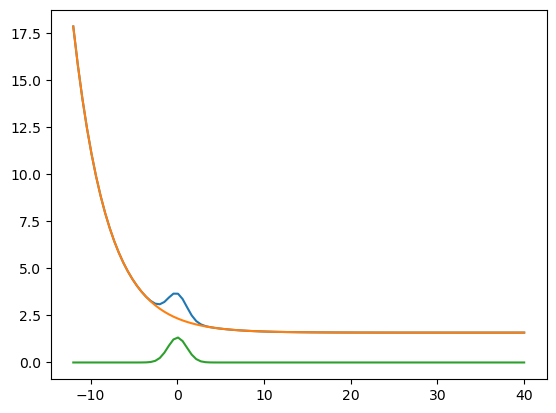

signal to background ratio for this trial is: 0.32463627973551973


In [ ]:
# Define and train the model using the best parameters found with sampling

latent_dim = 14
depth = 1
hidden_dim = 62
shrink_factor = 0.6395786091789358
learning_rate = 0.009994343982968336
weight_decay = 6.866255767127823e-05
epochs = 290
alpha = 0.568512304090592

loss_vs_epoch, outputs, model = train_model(
    Autoencoder(latent_dim,depth,hidden_dim, shrink_factor), 
    loader_KDAE_train_data,
    alpha=alpha,
    learning_rate=learning_rate,
    weight_decay=weight_decay,
    epochs=epochs
    )


C:\Users\sande\AppData\Local\Temp\ipykernel_17756\3871533046.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  recon_error = torch.mean(np.abs(x - recon), dim=1)


              precision    recall  f1-score   support

         0.0       1.00      0.95      0.97   4677168
         1.0       0.00      0.33      0.00      1155

    accuracy                           0.95   4678323
   macro avg       0.50      0.64      0.49   4678323
weighted avg       1.00      0.95      0.97   4678323

Confusion matrix:
 [[4443632  233536]
 [    774     381]]


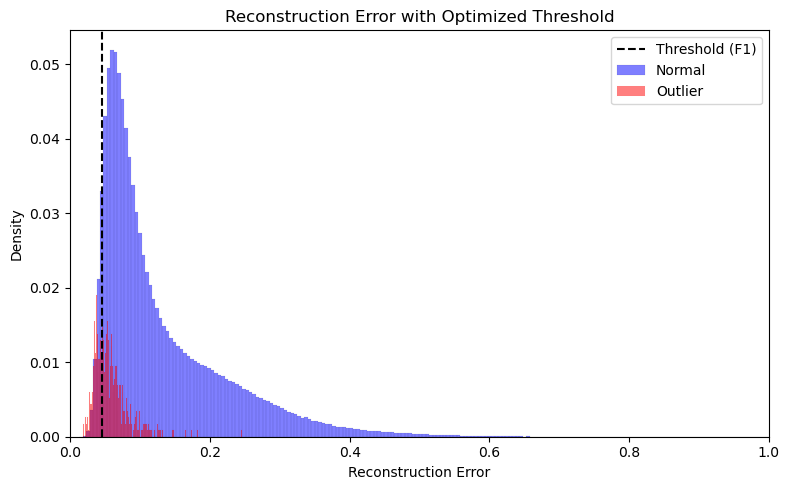

C:\Users\sande\AppData\Local\Temp\ipykernel_17756\3871533046.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  recon_error = torch.mean(np.abs(x - recon), dim=1)
C:\Users\sande\AppData\Local\Temp\ipykernel_17756\3097453322.py:9: RuntimeWarning: invalid value encountered in power
  return a*b**(-x-c-11)+d
C:\Users\sande\AppData\Local\Temp\ipykernel_17756\3097453322.py:68: OptimizeWarning: Covariance of the parameters could not be estimated
  param_2, param_cov_2 = curve_fit(bump_gaussian, bins,hist)


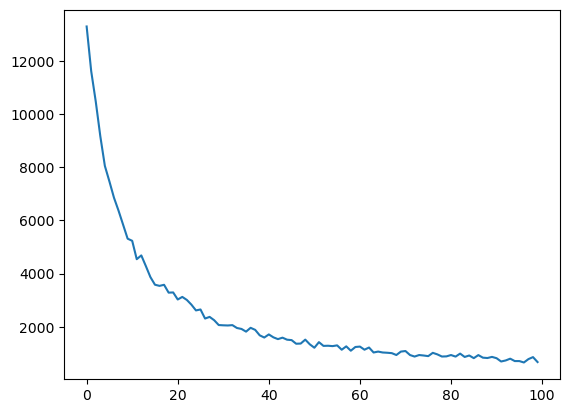

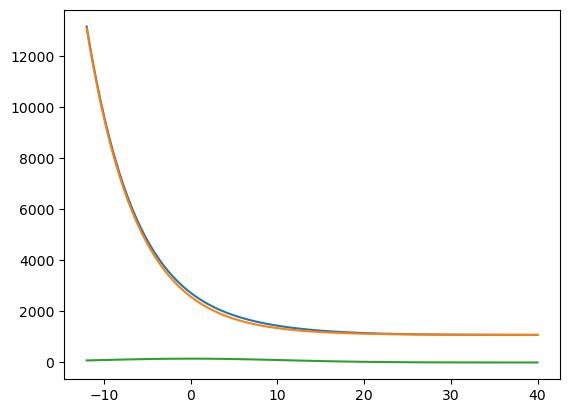

signal to background ratio for this trial is: 0.011186884002502897


In [24]:

# Collect mixed data
device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)
latent_test, recon_test, y_test, x_test = collect_latent_and_error(
    model, loader_mixed_data, device
)

# --- Performance evaluation ---
best_threshold_f1, best_f1 = find_f1_threshold(y_test,recon_test)
pred_labels = (recon_test < best_threshold_f1).astype(int)
signal_mask = recon_test < best_threshold_f1
print(classification_report(y_test, pred_labels))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))

plt.figure(figsize=(8,5))
sns.histplot(recon_test[y_test==0], color='blue', label='Normal', bins=1000, alpha=0.5,stat='proportion')
sns.histplot(recon_test[y_test==1], color='red', label='Outlier', bins=1000,alpha=0.5,stat='proportion')
plt.axvline(best_threshold_f1, color='black', linestyle='--', label='Threshold (F1)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.xlim(0,1)
plt.title("Reconstruction Error with Optimized Threshold")
plt.legend()
plt.tight_layout()
plt.show()

# We have now classified the signal from the background (not necessarily very well). Give the signal we found in the background noise a label D+ = True
latent_noise, recon_noise, y_noise, x_noise = collect_latent_and_error(
    model, loader_noise_data, device
)

# Apply the classification on the inclusive dataset.
candidate_mask=recon_noise < best_threshold_f1
candidates = x_noise[candidate_mask]

# Hunt the distribution of candidates for a bump
_,_,SoverB = bump_hunt(candidates,bins=200)

print(f"signal to background ratio for this trial is: {SoverB}")

C:\Users\sande\AppData\Local\Temp\ipykernel_4896\3871533046.py:15: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  recon_error = torch.mean(np.abs(x - recon), dim=1)


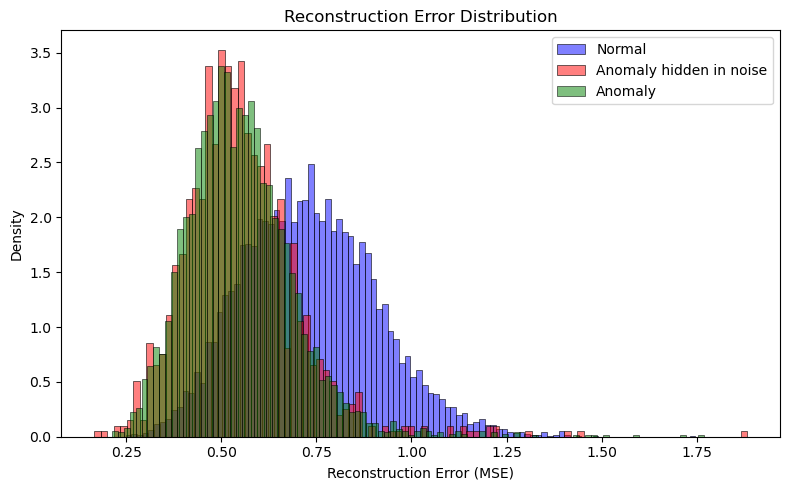

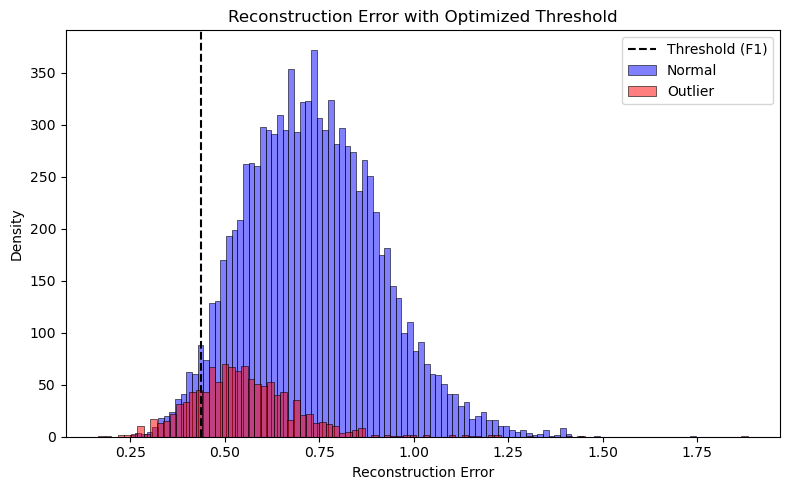

0.7400969087386491
              precision    recall  f1-score   support

         0.0       0.91      0.97      0.94     10000
         1.0       0.41      0.20      0.27      1155

    accuracy                           0.89     11155
   macro avg       0.66      0.58      0.60     11155
weighted avg       0.86      0.89      0.87     11155

Confusion matrix:
 [[9673  327]
 [ 924  231]]


In [14]:
# --- Visualization ---
# Collect TRAIN (normal) data
model = best_model
device = "cuda" if torch.cuda.is_available() else "cpu"

latent_train, recon_train, y_train, _ = collect_latent_and_error(
    model, loader_KDAE_train_data, device
)
latent_test, recon_test, y_test, _ = collect_latent_and_error(
    model, loader_mixed_data, device
)
best_threshold_f1, best_f1 = find_f1_threshold(y_test,recon_test)

# plt.style.use('fivethirtyeight')
# plt.figure(figsize=(8, 5))
# plt.plot(loss_vs_epoch, label='Loss')
# plt.xlabel('Iterations')
# plt.ylabel('Loss')
# plt.legend()
# plt.show()


plt.figure(figsize=(8, 5))
sns.histplot(
    recon_test[y_test == 0],
    bins=100,
    stat="density",
    label="Normal",
    color="blue",
    alpha=0.5,
)
sns.histplot(
    recon_test[y_test == 1],
    bins=100,
    stat="density",
    label="Anomaly hidden in noise",
    color="red",
    alpha=0.5,
)

sns.histplot(
    recon_train[y_train == 1],
    bins=100,
    stat="density",
    label="Anomaly",
    color="green",
    alpha=0.5,
)
plt.xlabel("Reconstruction Error (MSE)")
plt.title("Reconstruction Error Distribution")
plt.legend()
plt.tight_layout()
plt.show()

plt.figure(figsize=(8,5))
sns.histplot(recon_test[y_test==0], color='blue', label='Normal', bins=100, alpha=0.5)
sns.histplot(recon_test[y_test==1], color='red', label='Outlier', bins=100, alpha=0.5)
plt.axvline(best_threshold_f1, color='black', linestyle='--', label='Threshold (F1)')
plt.xlabel("Reconstruction Error")
plt.ylabel("Density")
plt.title("Reconstruction Error with Optimized Threshold")
plt.legend()
plt.tight_layout()
plt.show()
print(best_f1)

pred_labels = (recon_test < best_threshold_f1).astype(int)
signal_mask = recon_test < best_threshold_f1
print(classification_report(y_test, pred_labels))
print("Confusion matrix:\n", confusion_matrix(y_test, pred_labels))

BUMP HUNT

In [1]:


latent_noise, recon_noise, y_noise, x_noise = collect_latent_and_error(
    model, loader_noise_data, device
)

# Apply the classification on the inclusive dataset.
candidate_mask=recon_noise < best_threshold_f1
candidates = x_noise[candidate_mask]

sns.histplot(candidates,bins=200)
# Hunt the distribution of candidates for a bump
_,_,SoverB = bump_hunt(candidates)

print(f"signal to background ratio for this trial is: {SoverB}")




NameError: name 'collect_latent_and_error' is not defined